# Projeto Sprint 7 - Zuber 

In [1]:
#Bibliotecas 

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
from scipy import stats as st
import math as m 

In [2]:
#importando os datasets

trips = pd.read_csv('moved_project_sql_result_01.csv')
locations = pd.read_csv('moved_project_sql_result_04.csv')
average_trip = pd.read_csv('moved_project_sql_result_07.csv')

### Análisando os Dados das Tabelas 

In [3]:
#Analisando o dataset da tabela trips.

trips.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


In [4]:
#Analisando as linhas do dataset da tabela trips.

trips.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


A tabela trips não tem valores nulos/ausentes e os dados estão com o dtypes correto. 

In [5]:
#Analisando o dataset da tabela locations.

locations.info()

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


In [6]:
#Analisando as linhas do dataset da tabela locations.

locations.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


A tabela locations não tem valores nulos/ausentes e os dados estão com o dtypes correto. 

In [7]:
#Analisando o dataset da tabela average_trip.

average_trip.info()

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 25.2 KB


In [8]:
#Convertendo a coluna 'start_time' para o formato datetime.
average_trip['start_ts'] = pd.to_datetime(average_trip['start_ts'])

In [9]:
#Analisando as linhas do dataset da tabela average_trip.

average_trip.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


A tabela average_trip não tem valores nulos/ausentes, porém optei por converter a coluna 'start_ts' de str para datetime, para ficar no formato correto,  mesmo que necesse caso não seja necessário, visto que a tabela já foi filtrada em SQL.

## Gráficos 

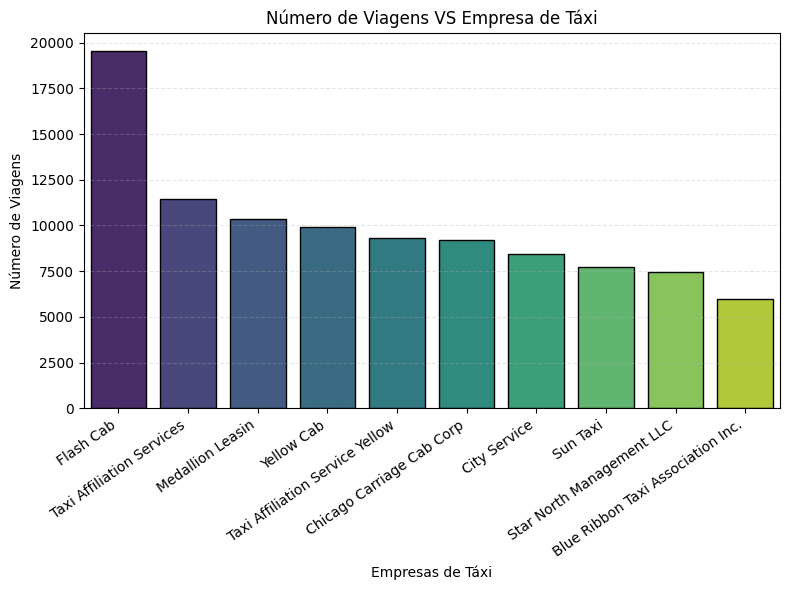

In [10]:
#Grafico de barras do número de viagens por empresa de táxi.
top10_companies = trips.head(10)
plt.figure(figsize=(8,6))
sns.barplot(x='company_name',
            y='trips_amount',
            data  = top10_companies,
            palette='viridis',
            hue ='company_name',
            edgecolor='black')       
plt.title('Número de Viagens VS Empresa de Táxi')
plt.xlabel('Empresas de Táxi')   
plt.ylabel('Número de Viagens')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


O gráfico ilustra as 10 principais empresas de táxi e o número de viagens que realizaram.Com base na analise das top 10 empresas de taxi, podemos notar uma dominância por parte das viagens da empresa Flash Cab que tem um número superior da segunda colocada Taxi Affiliation Services  e das demais empresas do top 10. Pode ser tratar que um meio competitivo se formos falar das demais empresas que estão nesse top 10 que criamos.

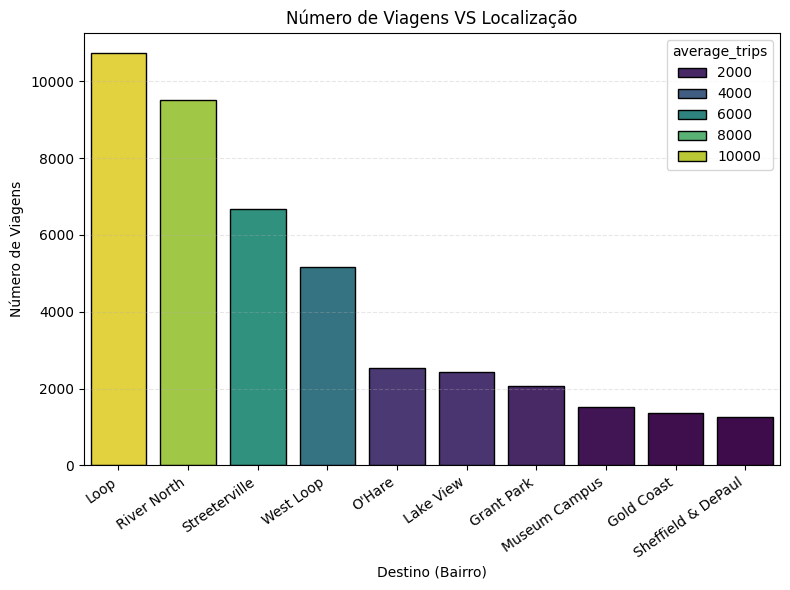

In [11]:
#Top10 de destinos mais populares.
top10_locations = locations.head(10)

#Grafico de barras do número de viagens por localização(destino).
plt.figure(figsize=(8,6))      
sns.barplot(x='dropoff_location_name',
            y='average_trips',
            data  = top10_locations,
            palette='viridis',
            hue ='average_trips',
            edgecolor='black')
plt.title('Número de Viagens VS Localização')
plt.xlabel('Destino (Bairro)')
plt.ylabel('Número de Viagens')
plt.xticks(rotation=35, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico ilustra as 10 principais destinos e o número de viagens que realizaram para eles. Com base na analise das top 10 destinos podemos notar que os  4 primeiro destinos (Loop, River North, Streetville e West Loop) com maiores viagens se trata de uma zona bem movimentada e cheia de coisas para fazer seja trabalho ou turismo, os bairros chegam a ser um complemento entre si, depois desses destinos, temos o aeroporto - O'Hare. Por isso acredito que o maior número de usuários possa ser de turismo ou pessoas que apenas estão a trabalho mas de passagens e que as pessoas que realmente moram em Chicago conhecem outro meio de se locomover, seja ele metro ou ônibus.

## Testando hipóteses

Baseando-se no alto nível de viagem que as empresas de táxi realizam, queremos saber se em sábado chuvosos ou não chuvosos o tempo de viagem aumentam.

H₀: A duração média dos passeios do Loop para O'Hare é igual entre sábados chuvosos e sábados não-chuvosos.                        

H₁:  A duração média dos passeios do Loop para O'Hare é diferente entre sábados chuvosos e sábados não-chuvosos.

In [12]:
#Verificando as opções de condições climáticas presentes no dataset average_trip.

average_trip['weather_conditions'].unique()

<StringArray>
['Good', 'Bad']
Length: 2, dtype: str

In [13]:
#Filtrando os dados para obter apenas os registros de sábado chuvoso e sábado ensolarado.

sabado_chuvoso = average_trip[average_trip['weather_conditions'] == 'Bad']
sabado_ensolarado = average_trip[average_trip['weather_conditions'] == 'Good']

In [14]:
#Calculando as variancias
variancia_chuvoso = sabado_chuvoso['duration_seconds'].var()
variancia_ensolarado = sabado_ensolarado['duration_seconds'].var()

#Verificando se as variâncias são iguais ou diferentes para escolher o teste estatístico adequado.
variancias = variancia_ensolarado / variancia_chuvoso

if 0.5 <= variancias <= 2.0:
    variancias_iguais = True
    print("As variâncias são consideradas iguais.")
else:
    print("As variâncias são diferentes. ")

As variâncias são consideradas iguais.


In [15]:
# Filtrar para sábados com tempo bom
amostra1 = average_trip[average_trip['weather_conditions'] == 'Good']['duration_seconds']

# Filtrar para sábados chuvosos  
amostra2 = average_trip[average_trip['weather_conditions'] == 'Bad']['duration_seconds']

In [16]:
#Testando a hipótese de que a duração média das viagens é igual em sabado chuvoso e em sabado ensolarado.

alpha = 0.05 #Nível de significância.

results = st.ttest_ind(amostra1, amostra2, equal_var=False)
print('valor-p:', results.pvalue)

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
    print("Há diferença significativa entre os grupos")
else:
    print("Não podemos rejeitar a hipótese nula")
    print("Não há evidência de diferença ")


valor-p: 6.738994326108735e-12
Rejeitamos a hipótese nula
Há diferença significativa entre os grupos


O teste de hipótese nós mostra que sim, em sábados chuvosos tem aumento no tempo de corrida de Loop para o aeroporto O'hare.

In [ ]:
#Calculando as médias de duração das viagens para sábado chuvoso e sábado ensolarado.
media_sabado_chuvoso = sabado_chuvoso['duration_seconds'].mean()
media_sabado_ensolarado = sabado_ensolarado['duration_seconds'].mean()

#Convertendo as médias de segundos para minutos.
media_sabado_chuvoso_min = media_sabado_chuvoso / 60
media_sabado_ensolarado_min = media_sabado_ensolarado / 60

#Exibindo as médias de duração das viagens para sábado chuvoso e sábado ensolarado em minutos.
print(f"Média tempo ensolarado: {media_sabado_ensolarado_min:.2f} minutos")
print(f"Média tempo chuvoso: {media_sabado_chuvoso_min:.2f} minutos")

Média tempo ensolarado: 33.33 minutos
Média tempo chuvoso: 40.45 minutos
